In [20]:
import numpy as np
import tensorflow as tf
import tensorflow.keras as K
from tensorflow.keras.layers import Input, Dense, Reshape, Flatten
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import LeakyReLU
from tensorflow.keras import Sequential, Model
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from skimage.transform import resize
from tensorflow.keras import layers, Model, optimizers
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, average_precision_score
import scipy.io
import itertools
import time
import shutil
import os

In [21]:
def wasserstein_loss(y_true, y_pred):
    return tf.reduce_mean(y_true * y_pred)
class WGAN:
    def __init__(self, output_dir='wgan_generated_output', model_dir='wgan_saved_models'):
        # Image dimensions
        self.img_rows = 32
        self.img_cols = 32
        self.channels = 3
        self.img_shape = (self.img_rows, self.img_cols, self.channels)

        # Number of classes for auxiliary classification (including 'fake' class)
        self.num_classes = 4
        # Dimension of the latent space
        self.latent_dim = 100

        # Directories
        self.output_dir = output_dir
        self.model_dir = model_dir

        # Create directories if missing
        os.makedirs(self.output_dir, exist_ok=True)
        os.makedirs(self.model_dir, exist_ok=True)

        # History dict
        self.training_history = {
            'D_loss': [],
            'D_cls_acc': [],
            'G_loss': []
        }

        # Build and compile the critic (alias as discriminator)
        self.critic = self.build_critic()
        self.discriminator = self.critic  # alias for compatibility
        optimizer = optimizers.RMSprop(lr=0.00005)
        self.critic.compile(
            loss=[wasserstein_loss, 'categorical_crossentropy'],
            loss_weights=[1.0, 0.5],
            optimizer=optimizer,
            metrics=[None, 'accuracy']
        )

        # Build the generator
        self.generator = self.build_generator()

        # Build the combined model (generator -> critic)
        self.critic.trainable = False
        z = layers.Input(shape=(self.latent_dim,))
        img = self.generator(z)
        validity, _ = self.critic(img)
        self.combined = Model(z, validity)
        self.combined.compile(loss=wasserstein_loss, optimizer=optimizer)

    def build_generator(self):
        model = tf.keras.Sequential([
            layers.Dense(128 * 8 * 8, activation="relu", input_dim=self.latent_dim),
            layers.Reshape((8, 8, 128)),
            layers.UpSampling2D(),
            layers.Conv2D(128, kernel_size=3, padding="same"),
            layers.BatchNormalization(momentum=0.8),
            layers.Activation("relu"),
            layers.UpSampling2D(),
            layers.Conv2D(64, kernel_size=3, padding="same"),
            layers.BatchNormalization(momentum=0.8),
            layers.Activation("relu"),
            layers.Conv2D(self.channels, kernel_size=3, padding="same"),
            layers.Activation("tanh")
        ])

        noise = layers.Input(shape=(self.latent_dim,))
        img = model(noise)
        return Model(noise, img)

    def build_critic(self):
        img = layers.Input(shape=self.img_shape)
        x = layers.Conv2D(32, kernel_size=3, strides=2, padding="same")(img)
        x = layers.LeakyReLU(alpha=0.2)(x)
        x = layers.Dropout(0.25)(x)

        x = layers.Conv2D(64, kernel_size=3, strides=2, padding="same")(x)
        x = layers.ZeroPadding2D(padding=((0,1),(0,1)))(x)
        x = layers.BatchNormalization(momentum=0.8)(x)
        x = layers.LeakyReLU(alpha=0.2)(x)
        x = layers.Dropout(0.25)(x)

        x = layers.Conv2D(128, kernel_size=3, strides=2, padding="same")(x)
        x = layers.BatchNormalization(momentum=0.8)(x)
        x = layers.LeakyReLU(alpha=0.2)(x)
        x = layers.Dropout(0.25)(x)

        x = layers.Conv2D(256, kernel_size=3, strides=1, padding="same")(x)
        x = layers.BatchNormalization(momentum=0.8)(x)
        x = layers.LeakyReLU(alpha=0.2)(x)
        x = layers.Dropout(0.25)(x)

        x = layers.Flatten()(x)

        # Wasserstein score output (linear)
        validity = layers.Dense(1, activation=None)(x)
        # Auxiliary classification head
        label    = layers.Dense(self.num_classes + 1, activation="softmax")(x)

        return Model(img, [validity, label])

    def train(self, X_train, y_train, X_test, y_test, epochs, batch_size, save_interval):
        # Real = -1, Fake = +1
        valid_y = -np.ones((batch_size, 1))
        fake_y  =  np.ones((batch_size, 1))

        for epoch in range(epochs):
            # Train critic multiple times per generator step
            for _ in range(5):
                idx = np.random.randint(0, X_train.shape[0], batch_size)
                real_imgs = X_train[idx]
                real_labels = to_categorical(y_train[idx], num_classes=self.num_classes+1)

                noise = np.random.normal(0, 1, (batch_size, self.latent_dim))
                fake_imgs = self.generator.predict(noise)
                fake_labels = to_categorical(
                    np.full((batch_size,), self.num_classes),
                    num_classes=self.num_classes+1
                )

                d_loss_real = self.critic.train_on_batch(real_imgs, [valid_y, real_labels])
                d_loss_fake = self.critic.train_on_batch(fake_imgs, [fake_y, fake_labels])
                d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

                # Weight clipping
                for layer in self.critic.layers:
                    for w in layer.get_weights():
                        clipped = [np.clip(arr, -0.01, 0.01) for arr in layer.get_weights()]
                        layer.set_weights(clipped)

            # Generator update
            noise = np.random.normal(0, 1, (batch_size, self.latent_dim))
            g_loss = self.combined.train_on_batch(noise, valid_y)

            # Record history
            self.training_history['D_loss'].append(d_loss[0])
            self.training_history['D_cls_acc'].append(100 * d_loss[3])
            self.training_history['G_loss'].append(g_loss)

            # Save and evaluate at intervals
            if epoch % save_interval == 0:
                self.evaluate_critic(X_test, y_test)
                self.save_imgs(epoch)

            print(f"Epoch {epoch} [D loss: {d_loss[0]:.4f}, cls acc.: {100*d_loss[3]:.2f}%] [G loss: {g_loss:.4f}]")

    def evaluate_critic(self, X_test, y_test):
        valid = -np.ones((y_test.shape[0], 1))
        labels = to_categorical(y_test, num_classes=self.num_classes+1)
        scores = self.critic.evaluate(X_test, [valid, labels], verbose=0)
        print(f"Critic eval [total: {scores[0]:.4f}, cls loss: {scores[2]:.4f}, cls acc.: {scores[3]*100:.2f}%]")
        return scores

    def save_imgs(self, epoch):
        os.makedirs(self.output_dir, exist_ok=True)
        r, c = 5, 5
        noise = np.random.normal(0, 1, (r * c, self.latent_dim))
        gen_imgs = self.generator.predict(noise)
        gen_imgs = 0.5 * gen_imgs + 0.5

        fig, axs = plt.subplots(r, c, figsize=(c, r))
        cnt = 0
        for i in range(r):
            for j in range(c):
                axs[i, j].imshow(gen_imgs[cnt])
                axs[i, j].axis('off')
                cnt += 1
        fig.savefig(os.path.join(self.output_dir, f"epoch_{epoch}.png"))
        plt.close(fig)

    def save_model(self):
        os.makedirs(self.model_dir, exist_ok=True)
        def _save(model, name):
            with open(os.path.join(self.model_dir, f"{name}.json"), 'w') as f:
                f.write(model.to_json())
            model.save_weights(os.path.join(self.model_dir, f"{name}_weights.h5"))
        _save(self.generator, "generator")
        _save(self.critic, "critic")
        _save(self.combined, "combined")

    def plot_training_history(self):
        fig, axs = plt.subplots(1, 2, figsize=(14,5))
        axs[0].plot(self.training_history['D_cls_acc'], label='Critic cls acc')
        axs[0].set_title('Critic Classification Accuracy')
        axs[0].set_ylabel('Accuracy (%)')
        axs[0].set_xlabel('Epoch')
        axs[0].legend()

        axs[1].plot(self.training_history['D_loss'], label='Critic loss')
        axs[1].plot(self.training_history['G_loss'], label='Generator loss')
        axs[1].set_title('WGAN Losses')
        axs[1].set_ylabel('Loss')
        axs[1].set_xlabel('Epoch')
        axs[1].legend()
        plt.show()

    def predict(self, X_test, y_test):
        y_pred_out = self.critic.predict(X_test)
        if isinstance(y_pred_out, list):
            class_logits = y_pred_out[1]
        else:
            class_logits = y_pred_out
        if class_logits.shape[1] == self.num_classes + 1:
            class_probs = class_logits[:, :self.num_classes]
        else:
            class_probs = class_logits
        y_test_oh = to_categorical(y_test, num_classes=self.num_classes)
        avep = average_precision_score(y_test_oh, class_probs, average='macro')
        print(f"Average Precision: {avep*100:.2f}%")
        y_pred_labels = np.argmax(class_probs, axis=1)
        acc = accuracy_score(y_test, y_pred_labels)
        print(f"Overall accuracy: {acc*100:.2f}%")
        print("Classification Report:\n", classification_report(y_test, y_pred_labels, zero_division=0))
        cm = confusion_matrix(y_test, y_pred_labels)
        self._plot_confusion_matrix(cm, [f"Class {i}" for i in range(self.num_classes)])

    def _plot_confusion_matrix(self, cm, classes, normalize=False, title='Confusion matrix'):
        if normalize:
            cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        plt.title(title)
        plt.colorbar()
        ticks = np.arange(len(classes))
        plt.xticks(ticks, classes, rotation=45)
        plt.yticks(ticks, classes)
        fmt = '.2f' if normalize else 'd'
        thresh = cm.max() / 2.
        for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
            plt.text(j, i, format(cm[i, j], fmt), horizontalalignment="center",
                     color="white" if cm[i, j] > thresh else "black")
        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        plt.tight_layout()


        




In [22]:
def load_cell_dataset_npy(cell_dir):
    """
    -----------------------------------------------------------------------------------------------
     Load pre-cropped cell images from .npy files
    -----------------------------------------------------------------------------------------------
    """
    X_train = np.load(f'{cell_dir}/X_train.npy')
    X_test = np.load(f'{cell_dir}/X_test.npy')
    y_train = np.load(f'{cell_dir}/y_train.npy')
    y_test = np.load(f'{cell_dir}/y_test.npy')

    """
    -----------------------------------------------------------------------------------------------
     Resize images to 32x32 if needed
    -----------------------------------------------------------------------------------------------
    """
    X_train_resized = np.empty([X_train.shape[0], 32, 32, 3])
    for i in range(X_train.shape[0]):
        X_train_resized[i] = resize(X_train[i], (32, 32, 3), mode='reflect')

    X_test_resized = np.empty([X_test.shape[0], 32, 32, 3])
    for i in range(X_test.shape[0]):
        X_test_resized[i] = resize(X_test[i], (32, 32, 3), mode='reflect')

    """
    -----------------------------------------------------------------------------------------------
     Normalize images from [0..1] to [-1..1]
    -----------------------------------------------------------------------------------------------
    """
    X_train_resized = 2 * X_train_resized - 1
    X_test_resized = 2 * X_test_resized - 1

    return X_train_resized, y_train, X_test_resized, y_test

In [23]:
X_train, y_train, X_test, y_test = load_cell_dataset_npy('dataset_A/cell_level_label')
print("Unique labels in y_train:", np.unique(y_train))
print("Unique labels in y_test:", np.unique(y_test))
gan=WGAN()

Unique labels in y_train: [0 1 2 3]
Unique labels in y_test: [0 1 2 3]


c:\Users\aditi\miniconda3\envs\gan_env\lib\site-packages\keras\optimizers\optimizer_v2\rmsprop.py:140: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [24]:
start = time.time() 
gan.train(X_train, y_train, X_test, y_test, epochs=2000, batch_size=32, save_interval=10)
end = time.time()
print ("\nTraining time: %0.1f minutes \n" % ((end-start) / 60))
gan.save_model()

1/1 [==============================] - 0s 79ms/step
Critic eval [total: 0.8040, cls loss: 1.6094, cls acc.: 0.00%]
1/1 [==============================] - 0s 255ms/step
Epoch 0 [D loss: 0.8046, cls acc.: 0.00%] [G loss: -0.0008]
1/1 [==============================] - 0s 87ms/step
Epoch 1 [D loss: 0.8043, cls acc.: 0.00%] [G loss: -0.0009]
1/1 [==============================] - 0s 83ms/step
Epoch 2 [D loss: 0.8041, cls acc.: 0.00%] [G loss: -0.0012]
1/1 [==============================] - 0s 66ms/step
Epoch 3 [D loss: 0.8039, cls acc.: 0.00%] [G loss: -0.0014]
1/1 [==============================] - 0s 77ms/step
Epoch 4 [D loss: 0.8036, cls acc.: 0.00%] [G loss: -0.0017]
1/1 [==============================] - 0s 83ms/step
Epoch 5 [D loss: 0.8033, cls acc.: 0.00%] [G loss: -0.0020]
1/1 [==============================] - 0s 82ms/step
Epoch 6 [D loss: 0.8031, cls acc.: 0.00%] [G loss: -0.0021]
1/1 [==============================] - 0s 51ms/step
Epoch 7 [D loss: 0.8027, cls acc.: 0.00%] [G los

KeyboardInterrupt: 

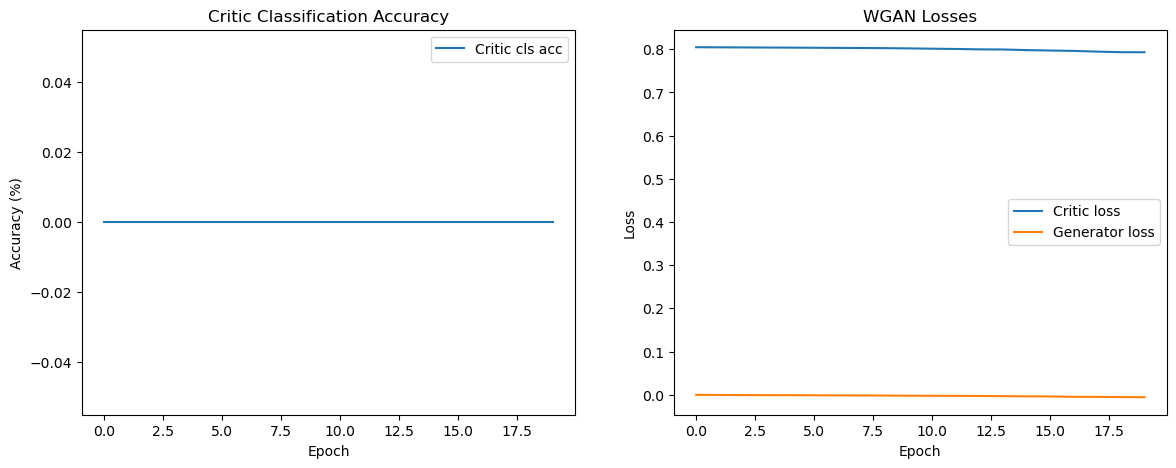

In [ ]:
gan.plot_training_history()

12/12 [==============================] - 1s 60ms/step
Average Precision: 27.57%
Overall accuracy: 36.26%
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00         9
           1       0.36      1.00      0.53       132
           2       0.00      0.00      0.00        92
           3       0.00      0.00      0.00       131

    accuracy                           0.36       364
   macro avg       0.09      0.25      0.13       364
weighted avg       0.13      0.36      0.19       364



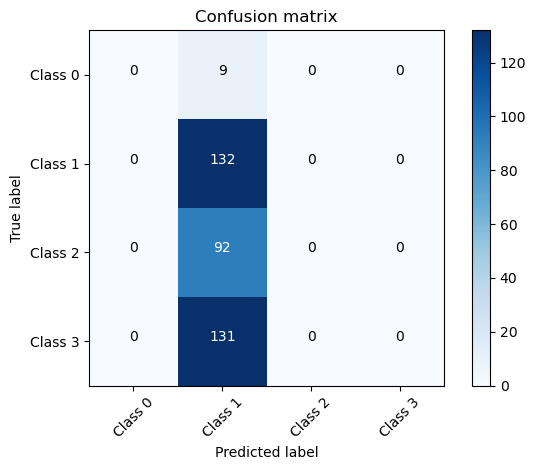

In [ ]:
gan.predict(X_test,y_test)